# Final figure — minimal notebook

Loads pre-computed Wigner transforms and reproduces the figure.

In [1]:
using PyPlot
using JLD2
using PyCall
using LaTeXStrings

mpl_ticker = pyimport("matplotlib.ticker")

rc("text", usetex=true)
rc("font", family="serif")
rc("font", size=18)
rc("axes", labelsize=22, titlesize=22)
rc("xtick", labelsize=18)
rc("ytick", labelsize=18)
rc("legend", fontsize=16)
plt.rc("axes", linewidth=2)

In [2]:
@inline function pulse_Gaussian_sin(t::Float64; t0::Float64, ω0::Float64,
                                     σ::Float64, A::Float64)
    A * exp(-0.5*(t-t0)^2/σ^2) * sin(t*ω0)
end

t0 = 25.0
ω0 = 3.0
σ  = 2.0
A  = 0.5
pulse(t) = pulse_Gaussian_sin(t; t0, ω0, σ, A)

pulse (generic function with 1 method)

In [3]:
data  = load("Data/wigner_precomputed.jld2")
GL_11 = data["GL_11"];  ωs_11 = data["ωs_11"]
GL_21 = data["GL_21"];  ωs_21 = data["ωs_21"]
GL_31 = data["GL_31"];  ωs_31 = data["ωs_31"]
GL_12 = data["GL_12"];  ωs_12 = data["ωs_12"]
GL_22 = data["GL_22"];  ωs_22 = data["ωs_22"]
GL_32 = data["GL_32"];  ωs_32 = data["ωs_32"]

487-element Vector{Float64}:
 -9.522993049375028
 -9.4838037775669
 -9.444614505758773
 -9.405425233950645
 -9.366235962142518
 -9.32704669033439
 -9.287857418526261
 -9.248668146718135
 -9.209478874910006
 -9.170289603101878
 -9.131100331293752
 -9.091911059485623
 -9.052721787677497
  ⋮
  9.091911059485625
  9.131100331293752
  9.170289603101878
  9.209478874910008
  9.248668146718135
  9.287857418526261
  9.327046690334388
  9.366235962142518
  9.405425233950645
  9.444614505758771
  9.483803777566902
  9.522993049375028

## Final figure

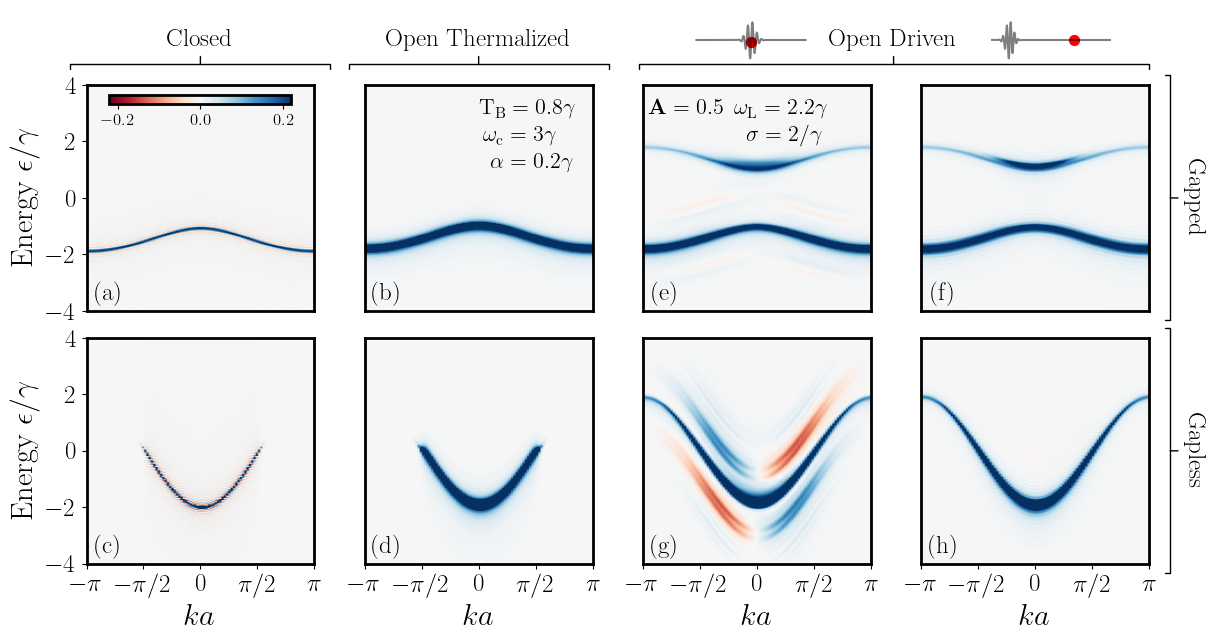

In [4]:
fig, axs = subplots(2, 4, figsize=(12, 6))

cmap = plt.get_cmap("RdBu", 3024)

axs[1,1].set_xticks([])
axs[1,2].set_xticks([])
axs[1,3].set_xticks([])
axs[1,4].set_xticks([])
axs[2,1].set_xticks([])
axs[2,2].set_xticks([])
axs[2,3].set_xticks([])
axs[2,4].set_xticks([])
axs[1,2].set_yticks([])
axs[1,3].set_yticks([])
axs[1,4].set_yticks([])
axs[2,2].set_yticks([])
axs[2,3].set_yticks([])
axs[2,4].set_yticks([])

axs[2,1].set_xlabel(raw"$ka$")
axs[2,1].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
axs[2,2].set_xlabel(raw"$ka$")
axs[2,2].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
axs[2,3].set_xlabel(raw"$ka$")
axs[2,3].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])
axs[2,4].set_xlabel(raw"$ka$")
axs[2,4].set_xticks([-π, -π/2, 0, π/2, π], [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"])

axs[1,1].set_ylabel(L"$\mathrm{Energy \ \epsilon/\gamma  }$")
axs[2,1].set_ylabel(L"$\mathrm{Energy \ \epsilon/\gamma  }$")
for ax in vec(axs)
    ax.set_ylim(-7, 7)
end

tight_layout()

axs[1,1].annotate(L"$\mathrm{Closed} $", xy=(0.5, 1.08), xytext=(0.5, 1.2), xycoords="axes fraction",
            ha="center", va="center", rotation=0.0,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=5.2, lengthB=0.2", "lw"=>1.0))

axs[1,2].annotate(L"$\mathrm{Open\ Thermalized} $", xy=(0.5, 1.08), xytext=(0.5, 1.2), xycoords="axes fraction",
            ha="center", va="center", rotation=0.0,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=5.2, lengthB=0.2", "lw"=>1.0))

axs[1,3].annotate(L"$\mathrm{Open\ Driven } $", xy=(1.1, 1.08), xytext=(1.1, 1.2), xycoords="axes fraction",
            ha="center", va="center", rotation=0.0,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=10.2, lengthB=0.2", "lw"=>1.0))

axs[1,4].annotate(L"$\mathrm{Gapped} $", xy=(1.08, 0.5), xytext=(1.2, 0.5), xycoords="axes fraction",
            ha="center", va="center", rotation=270,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=4.9, lengthB=0.2", "lw"=>1.0))

axs[2,4].annotate(L"$\mathrm{Gapless} $", xy=(1.08, 0.5), xytext=(1.2, 0.5), xycoords="axes fraction",
            ha="center", va="center", rotation=270,
           arrowprops=Dict("arrowstyle"=>"-[, widthB=4.9, lengthB=0.2", "lw"=>1.0))

ts = 0.0:0.1:50
ax2 = fig.add_axes([0.59, 0.98, 0.1, 0.1])
ax2.tick_params(left=false, bottom=false, labelleft=false, labelbottom=false)
ax2.plot(ts, pulse.(ts), color="black", alpha=0.5)
ax2.scatter(25.1, pulse(25.1), color="red", s=50)
for sp in ax2.spines.values()
    sp.set_visible(false)
end
ax2.set_facecolor("none")
ax2.patch.set_alpha(0)
ax2.set_ylim(-0.8, 0.8)

ts = 0.0:0.1:80
ax3 = fig.add_axes([0.84, 0.98, 0.1, 0.1])
ax3.tick_params(left=false, bottom=false, labelleft=false, labelbottom=false)
ax3.plot(ts, pulse.(ts), color="black", alpha=0.5)
plt.scatter(60.0, pulse(60.), color="red", s=50)
for sp in ax3.spines.values()
    sp.set_visible(false)
end
ax3.set_facecolor("none")
ax3.patch.set_alpha(0)
ax3.set_ylim(-0.8, 0.8)
ax3.set_xlim(15, 80)

vmin = 0.02
vmax = 0.02

t_avg = 100
datt = imag.(transpose(GL_11[:,end:-1:1,t_avg]))
img = axs[1,1].imshow(datt, aspect="auto", cmap=cmap, extent=[-pi, pi, ωs_11[1], ωs_11[end]], vmin=-(vmin+0.2), vmax=vmax+0.2)
box = axs[1,1].get_position()
cbar_ax = fig.add_axes([box.x0 + 0.10*box.width, box.y0 - 0.01 - 0.015 + 0.37, 0.80*box.width, 0.015])
cbar = fig.colorbar(img, cax=cbar_ax, orientation="horizontal")
cbar.ax.tick_params(labelsize=12)
axs[1,1].set_ylim(-4, 4)

t_avg = 300
datt = imag.(transpose(GL_21[:,end:-1:1,t_avg]))
axs[1,2].imshow(datt, aspect="auto", cmap=cmap, extent=[-pi, pi, ωs_21[1], ωs_21[end]], vmin=-vmin, vmax=vmax)
axs[1,2].set_ylim(-4, 4)

t_avg = 215
datt = imag.(transpose(GL_31[:,end:-1:1,t_avg]))
axs[1,3].imshow(datt, aspect="auto", cmap=cmap, extent=[-pi, pi, ωs_31[1], ωs_31[end]], vmin=-vmin, vmax=vmax)
axs[1,3].set_ylim(-4, 4)

t_avg = 360
datt = imag.(transpose(GL_31[:,end:-1:1,t_avg]))
axs[1,4].imshow(datt, aspect="auto", cmap=cmap, extent=[-pi, pi, ωs_31[1], ωs_31[end]], vmin=-vmin, vmax=vmax)
axs[1,4].set_ylim(-4, 4)

t_avg = 100
datt = imag.(transpose(GL_12[:,end:-1:1,t_avg]))
axs[2,1].imshow(datt, aspect="auto", cmap=cmap, extent=[-pi, pi, ωs_12[1], ωs_12[end]], vmin=-(vmin+0.2), vmax=vmax+0.2)
axs[2,1].set_ylim(-4, 4)

t_avg = 210
datt = imag.(transpose(GL_22[:,end:-1:1,t_avg]))
axs[2,2].imshow(datt, aspect="auto", cmap=cmap, extent=[-pi, pi, ωs_22[1], ωs_22[end]], vmin=-vmin, vmax=vmax)
axs[2,2].set_ylim(-4, 4)

t_avg = 180
datt = imag.(transpose(GL_32[:,end:-1:1,t_avg]))
axs[2,3].imshow(datt, aspect="auto", cmap=cmap, extent=[-pi, pi, ωs_32[1], ωs_32[end]], vmin=-vmin, vmax=vmax)
axs[2,3].set_ylim(-4, 4)

t_avg = 336
datt = imag.(transpose(GL_32[:,end:-1:1,t_avg]))
axs[2,4].imshow(datt, aspect="auto", cmap=cmap, extent=[-pi, pi, ωs_32[1], ωs_32[end]], vmin=-vmin, vmax=vmax)
axs[2,4].set_ylim(-4, 4)

index = [raw"$\rm{(a)}$", raw"$\rm{(c)}$", raw"$\rm{(b)}$", raw"$\rm{(d)}$",
         raw"$\rm{(e)}$", raw"$\rm{(g)}$", raw"$\rm{(f)}$", raw"$\rm{(h)}$"]
for (i, ax) in enumerate(axs)
    ax.text(x=0.1, y=0.05, s=index[i], ha="center", transform=ax.transAxes)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-1, 2), useMathText=true)
end

axs[1,2].text(x=0.5,  y=0.87, s=L"$\mathrm{T_B = 0.8\gamma}$",   transform=axs[1,2].transAxes, fontsize=16)
axs[1,2].text(x=0.52, y=0.75, s=L"$\mathrm{\omega_c = 3\gamma}$", transform=axs[1,2].transAxes, fontsize=16)
axs[1,2].text(x=0.55, y=0.63, s=L"$\mathrm{\alpha = 0.2\gamma}$", transform=axs[1,2].transAxes, fontsize=16)

axs[1,3].text(x=0.02, y=0.87, s=L"$\mathrm{\mathbf{A}= 0.5}$",      transform=axs[1,3].transAxes, fontsize=16)
axs[1,3].text(x=0.4,  y=0.87, s=L"$\mathrm{\omega_L = 2.2\gamma}$", transform=axs[1,3].transAxes, fontsize=16)
axs[1,3].text(x=0.45, y=0.75, s=L"$\mathrm{\sigma = 2/\gamma}$",    transform=axs[1,3].transAxes, fontsize=16)

axs[1,1].yaxis.set_major_locator(mpl_ticker.MaxNLocator(5))
axs[2,1].yaxis.set_major_locator(mpl_ticker.MaxNLocator(5))

plt.savefig("G_lesser.pdf", bbox_inches="tight")
